# Airline Passenger Satisfaction Prediction

## Model Training & Evaluation

### Objective

This notebook is where I actually train some models and see how they do.

**Models I'm comparing:**
- **Logistic Regression** — simple, fast, interpretable baseline (scaled features)
- **Random Forest** — handles non-linear relationships


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


### Load the engineered data

In [2]:
df_unscaled = pd.read_csv("../data/processed/airline_satisfaction_features.csv")
df_scaled = pd.read_csv("../data/processed/airline_satisfaction_features_scaled.csv")

print("Unscaled shape:", df_unscaled.shape)
print("Scaled shape:", df_scaled.shape)

df_unscaled.head()


Unscaled shape: (129487, 24)
Scaled shape: (129487, 24)


,Gender,Customer Type,Age,Type of Travel,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,...,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,class_Eco,class_Eco Plus,total_delay,avg_service_score,satisfaction
0,0,1,65,0,265,0,0,0,2,2,...,0,3,5,3,2,1,0,0.0,2.071429,1
1,1,1,47,0,2464,0,0,0,3,0,...,4,4,2,3,2,0,0,615.0,2.071429,1
2,0,1,15,0,2138,0,0,0,3,2,...,3,4,4,4,2,1,0,0.0,2.071429,1
3,0,1,60,0,623,0,0,0,3,3,...,0,1,4,1,3,1,0,0.0,1.714286,1
4,0,1,70,0,354,0,0,0,3,4,...,0,2,4,2,5,1,0,0.0,2.214286,1


### Train/test split

Split once on the unscaled data, then apply the same row indices to the scaled version, so every model is evaluated on exactly the same passengers.

In [3]:
X_unscaled = df_unscaled.drop(columns=["satisfaction"])
X_scaled = df_scaled.drop(columns=["satisfaction"])
y = df_unscaled["satisfaction"]

X_train_u, X_test_u, y_train, y_test, train_idx, test_idx = train_test_split(
    X_unscaled, y, X_unscaled.index,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train_s = X_scaled.loc[train_idx]
X_test_s = X_scaled.loc[test_idx]

print("Train shape:", X_train_u.shape, " Test shape:", X_test_u.shape)
print("Train satisfaction rate: {:.2%}".format(y_train.mean()))
print("Test satisfaction rate:  {:.2%}".format(y_test.mean()))


Train shape: (103589, 23)  Test shape: (25898, 23)
Train satisfaction rate: 54.74%
Test satisfaction rate:  54.74%


### Define the two candidate models

In [4]:
models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "X_train": X_train_s,
        "X_test": X_test_s,
    },
    "Random Forest": {
        "model": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
        "X_train": X_train_u,
        "X_test": X_test_u,
    },
}

list(models.keys())


['Logistic Regression', 'Random Forest']

### Cross-validate on the training set

5-fold cross-validation gives a more reliable read than a single split. Checking accuracy alongside F1 and ROC-AUC here with a roughly balanced target, I'd expect these to broadly agree, but worth confirming rather than assuming.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "roc_auc", "f1", "precision", "recall"]

cv_results = []

for name, spec in models.items():
    scores = cross_validate(spec["model"], spec["X_train"], y_train, cv=cv, scoring=scoring)
    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "F1": scores["test_f1"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("ROC-AUC", ascending=False)
cv_results_df


,Model,Accuracy,ROC-AUC,F1,Precision,Recall
1,Random Forest,0.956434,0.992725,0.959948,0.966234,0.953743
0,Logistic Regression,0.835909,0.909396,0.850241,0.849555,0.850930


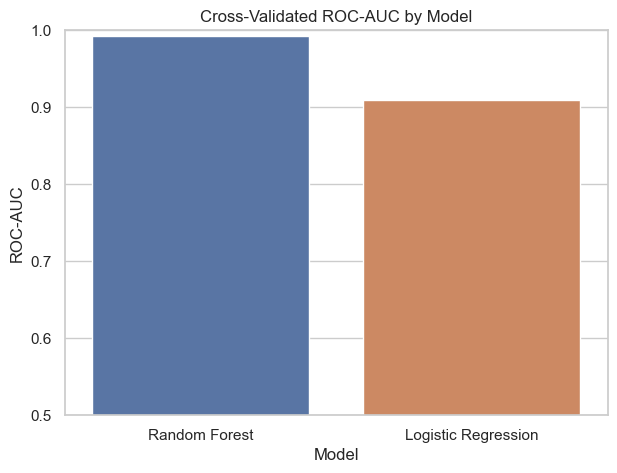

In [6]:
plt.figure(figsize=(7, 5))
sns.barplot(data=cv_results_df, x="Model", y="ROC-AUC")
plt.title("Cross-Validated ROC-AUC by Model")
plt.ylim(0.5, 1.0)
plt.savefig("../images/cv_roc_auc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


### Fit on the full training set, evaluate on the held-out test set

In [7]:
test_results = []
fitted_models = {}

for name, spec in models.items():
    model = spec["model"]
    model.fit(spec["X_train"], y_train)
    fitted_models[name] = model

    y_pred = model.predict(spec["X_test"])
    y_proba = model.predict_proba(spec["X_test"])[:, 1]

    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "F1": f1_score(y_test, y_pred),
    })

    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["Dissatisfied", "Satisfied"]))

test_results_df = pd.DataFrame(test_results).sort_values("ROC-AUC", ascending=False)
test_results_df


--- Logistic Regression ---
              precision    recall  f1-score   support

Dissatisfied       0.82      0.81      0.82     11721
   Satisfied       0.85      0.85      0.85     14177

    accuracy                           0.83     25898
   macro avg       0.83      0.83      0.83     25898
weighted avg       0.83      0.83      0.83     25898

--- Random Forest ---
              precision    recall  f1-score   support

Dissatisfied       0.94      0.96      0.95     11721
   Satisfied       0.97      0.95      0.96     14177

    accuracy                           0.96     25898
   macro avg       0.96      0.96      0.96     25898
weighted avg       0.96      0.96      0.96     25898



,Model,Accuracy,ROC-AUC,F1
1,Random Forest,0.956599,0.992888,0.960097
0,Logistic Regression,0.834350,0.907634,0.849018


### Confusion matrices

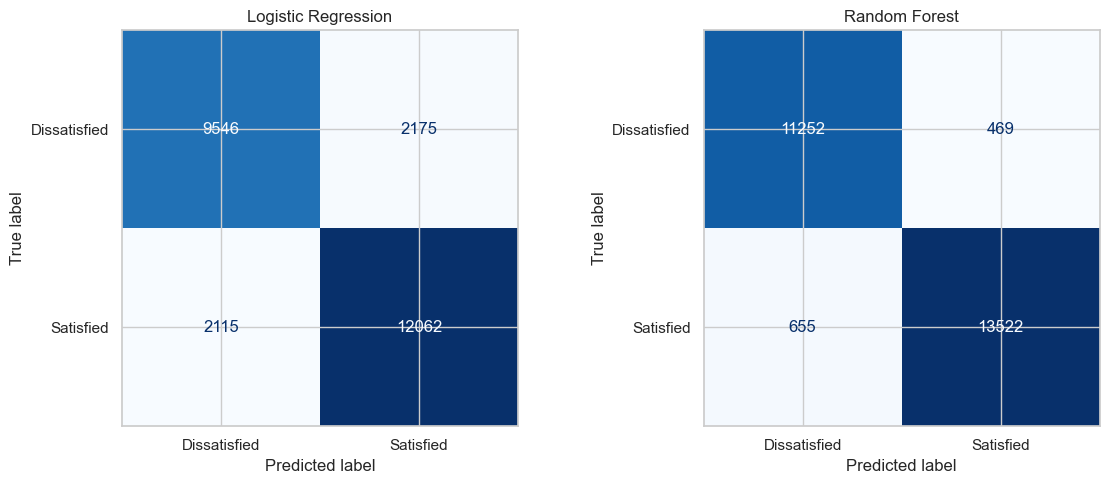

In [8]:
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))

for ax, (name, spec) in zip(axes, models.items()):
    model = fitted_models[name]
    y_pred = model.predict(spec["X_test"])
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Dissatisfied", "Satisfied"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.savefig("../images/confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()


Good news on the balance front neither model is lopsided toward one class. LogisticRegression makes roughly even mistakes both ways (2,175 false positives vs. 2,115 false negatives), and Random Forest is similarly balanced, just with way fewer mistakes overall (469 vs. 655). 

### ROC curve comparison

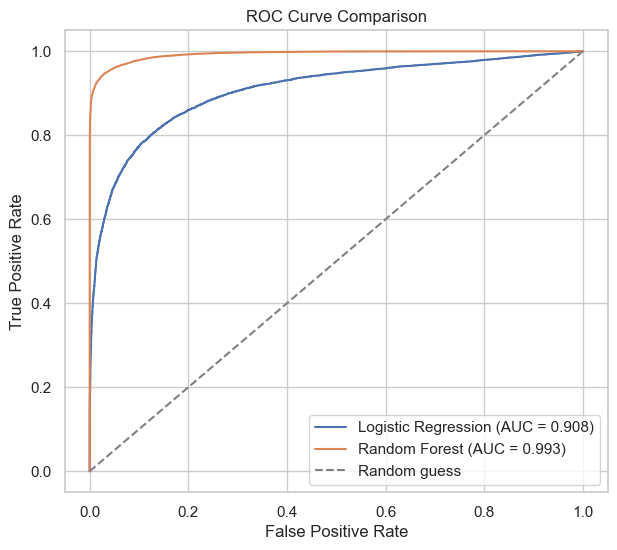

In [9]:
plt.figure(figsize=(7, 6))

for name, spec in models.items():
    model = fitted_models[name]
    y_proba = model.predict_proba(spec["X_test"])[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig("../images/roc_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


### Quick feature importance check (Random Forest)

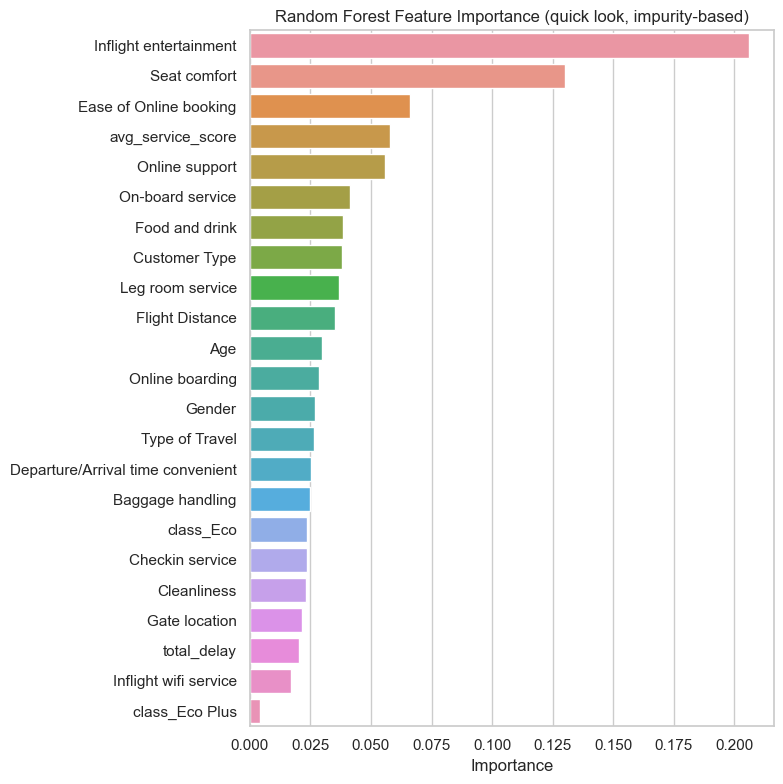

In [10]:
if "Random Forest" in fitted_models:
    importances = pd.Series(
        fitted_models["Random Forest"].feature_importances_,
        index=X_train_u.columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(8, 8))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title("Random Forest Feature Importance (quick look, impurity-based)")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("../images/rf_feature_importance_quicklook.png", dpi=300, bbox_inches="tight")
    plt.show()


This mostly lines up with what I found earlier, inflight entertainment is the clear number 1, and ease of online booking and online support show up near the top too, just like in the EDA and the correlation check on avg_service_score.

One thing that surprised me: seat comfort shows up as the number 2 most important feature here, even though it only had a moderate correlation (0.24) with satisfaction back in the EDA. Random Forest can over-weight certain features just based on how useful they are for splitting, not necessarily how strongly they correlate with the target on their own. I'll actually check this properly with permutation importance in the next notebook.

Also worth noting avg_service_score shows up respectably (4th) but not as dominant as I might've expected, probably because it's essentially just a blend of the same information already sitting in the 14 individual service columns so its "importance" ends up split across all of them instead of concentrated in one place.

### Select and save the best model

Picking the model with the highest test-set ROC-AUC.

In [11]:
best_model_name = test_results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

print(f"Best model by test ROC-AUC: {best_model_name}")
print(test_results_df)

os.makedirs("../models", exist_ok=True)
with open("../models/trained_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print(f"\nSaved {best_model_name} to ../models/trained_model.pkl")


Best model by test ROC-AUC: Random Forest
                 Model  Accuracy   ROC-AUC        F1
1        Random Forest  0.956599  0.992888  0.960097
0  Logistic Regression  0.834350  0.907634  0.849018

Saved Random Forest to ../models/trained_model.pkl


## Summary

- **Model comparison** I expected Logistic Regression and Random Forest to land pretty close together, since I didn't spot anything clearly non-linear. But Random Forest was much better, 99.3% ROC-AUC and 96% accuracy, compared to Logistic Regression's 90.8% and 83%. That's a big gap, and it held up consistently across both cross-validation and the held-out test set, so it's not just a fluke from one lucky split. This tells me there's more going on beneath the surface here than I picked up on in the EDA, some kind of non-linear pattern or interaction between features that a linear model just can't capture. I'm genuinely curious what permutation importance and SHAP turn up on this in the next notebook.

- **Class balance check:** both models handle the two classes fairly evenly. Random Forest's confusion matrix in particular is close to a clean diagonal (469 false positives, 655 false negatives out of ~26k test passengers).

- **Feature importance first look:** mostly matches expectations (inflight entertainment, ease of online booking, online support near the top), but seat comfort showing up as the 2nd feature was a surprise given its more modest EDA correlation 


**Next step:** permutation importance, SHAP values, and figuring out what's actually driving that surprisingly large gap between the two models.
